# Real-Time Fraud Detection System with Explainable AI & Live Dashboard

**Name:** Shreya Dey  
**Dataset:** IEEE-CIS Fraud Detection  
**Files used:** `train_transaction.csv` and `train_identity.csv`

This notebook shows my workflow for fraud detection: data loading, preprocessing, model training, SHAP explanations, risk segmentation, and dashboard export.


## Environment Setup

In [2]:
from pathlib import Path
import json
import math
import os
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, average_precision_score, classification_report,
    confusion_matrix, f1_score, precision_recall_curve, precision_score,
    recall_score, roc_auc_score, roc_curve
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, RobustScaler

from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
DASHBOARD_DIR = PROJECT_DIR / "dashboard"
CHART_DIR = PROJECT_DIR / "charts"
ARTIFACT_DIR = PROJECT_DIR / "artifacts"

for folder in [DATA_DIR, DASHBOARD_DIR, CHART_DIR, ARTIFACT_DIR]:
    folder.mkdir(exist_ok=True)

RANDOM_STATE = 42
N_SAMPLE = 120000


## TASK 1 - Data Loading, Merging & Exploratory Analysis

In [3]:
train_transaction_path = DATA_DIR / "train_transaction.csv"
train_identity_path = DATA_DIR / "train_identity.csv"

if not train_transaction_path.exists() or not train_identity_path.exists():
    raise FileNotFoundError(
        "Place Kaggle files in data/: train_transaction.csv and train_identity.csv"
    )

transaction = pd.read_csv(train_transaction_path)
identity = pd.read_csv(train_identity_path)
df = transaction.merge(identity, on="TransactionID", how="left")

if N_SAMPLE is not None and len(df) > N_SAMPLE:
    df = df.sample(N_SAMPLE, random_state=RANDOM_STATE).reset_index(drop=True)

print("Merged shape:", df.shape)
display(df.head(10))
display(df.dtypes.value_counts())


Merged shape: (120000, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,3457624,0,12153579,724.000,W,7826,481.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3552820,0,15005886,108.500,W,12544,321.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3271083,0,6970178,47.950,W,9400,111.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3226689,0,5673658,100.599,C,15885,545.0,185.0,visa,138.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3268855,0,6886780,107.950,W,15497,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,3400908,0,10444930,280.000,W,7919,194.0,150.0,mastercard,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,3400692,0,10442147,311.950,W,9002,453.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,3461182,0,12254683,330.990,W,14183,555.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,3357788,1,9228284,10.392,C,9633,130.0,185.0,visa,138.0,...,chrome generic,NaN,NaN,NaN,F,F,T,F,desktop,Windows
9,3015757,0,739585,335.000,W,11207,361.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


float64    399
object      31
int64        4
Name: count, dtype: int64

,count,percentage
isFraud,,
0,115692,96.41
1,4308,3.59


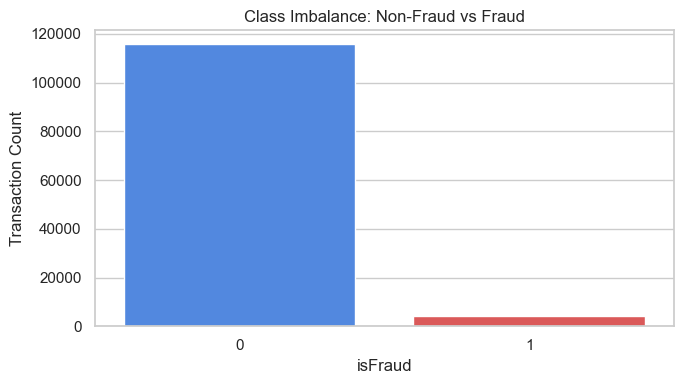

In [4]:
target_counts = df["isFraud"].value_counts().sort_index()
target_ratio = df["isFraud"].value_counts(normalize=True).sort_index() * 100
imbalance_table = pd.DataFrame({"count": target_counts, "percentage": target_ratio.round(2)})
display(imbalance_table)

plt.figure(figsize=(7, 4))
sns.barplot(x=imbalance_table.index.astype(str), y=imbalance_table["count"], palette=["#3B82F6", "#EF4444"])
plt.title("Class Imbalance: Non-Fraud vs Fraud")
plt.xlabel("isFraud")
plt.ylabel("Transaction Count")
plt.tight_layout()
plt.savefig(CHART_DIR / "class_imbalance.png", dpi=180)
plt.show()


In [5]:
missing = (
    df.isna().sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda x: (x["missing_count"] / len(df) * 100).round(2))
    .sort_values("missing_pct", ascending=False)
)
display(missing.head(30))

drop_threshold = 50
columns_to_drop = missing[missing["missing_pct"] > drop_threshold].index.tolist()
print(f"Columns with >{drop_threshold}% missing values:", len(columns_to_drop))


,missing_count,missing_pct
id_24,119049,99.21
id_21,118962,99.14
id_07,118962,99.14
id_08,118962,99.14
id_25,118965,99.14
id_23,118959,99.13
id_27,118959,99.13
id_26,118959,99.13
id_22,118959,99.13
dist2,112401,93.67


Columns with >50% missing values: 214


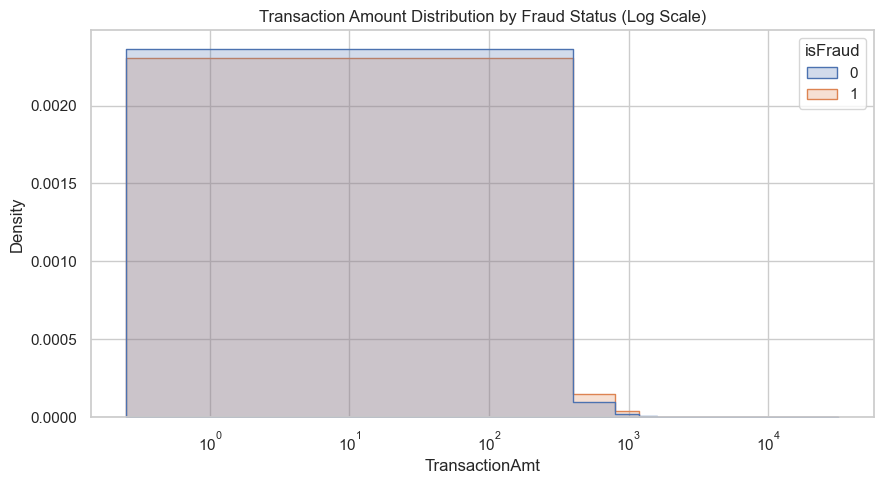

In [6]:
plt.figure(figsize=(9, 5))
sns.histplot(
    data=df, x="TransactionAmt", hue="isFraud",
    bins=80, stat="density", common_norm=False, element="step"
)
plt.xscale("log")
plt.title("Transaction Amount Distribution by Fraud Status (Log Scale)")
plt.tight_layout()
plt.savefig(CHART_DIR / "transaction_amount_distribution.png", dpi=180)
plt.show()


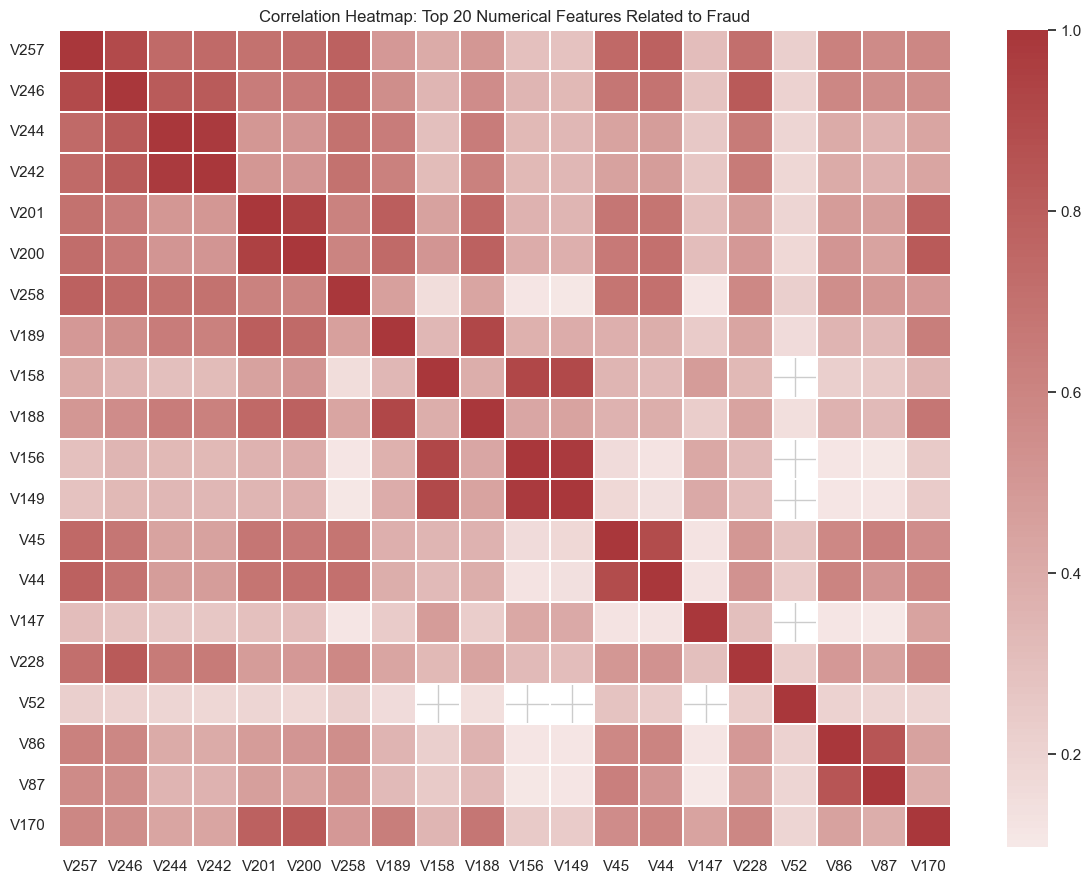

In [7]:
numeric_cols_for_corr = df.select_dtypes(include=np.number).columns.drop(["TransactionID", "isFraud"], errors="ignore")
top_corr_features = (
    df[numeric_cols_for_corr]
    .corrwith(df["isFraud"])
    .abs()
    .sort_values(ascending=False)
    .head(20)
    .index
)

plt.figure(figsize=(12, 9))
sns.heatmap(df[top_corr_features].corr(), cmap="vlag", center=0, linewidths=0.2)
plt.title("Correlation Heatmap: Top 20 Numerical Features Related to Fraud")
plt.tight_layout()
plt.savefig(CHART_DIR / "top20_correlation_heatmap.png", dpi=180)
plt.show()


## TASK 2 - Preprocessing, Imbalance Handling & Feature Engineering

### Encoding Strategy

I used ordinal encoding for categorical columns because this dataset has many high-cardinality fields. One-hot encoding would create too many columns and make the notebook slower. Tree-based models can still use ordinal-encoded categories.

Missing values:
- Drop columns with more than 50% missing values.
- Fill numerical columns with median.
- Fill categorical columns with mode.


In [8]:
def add_engineered_features(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    amount_mean = data["TransactionAmt"].mean()
    amount_std = data["TransactionAmt"].std()

    data["AmtToMeanRatio"] = data["TransactionAmt"] / max(amount_mean, 1e-9)
    data["AmtZScore"] = (data["TransactionAmt"] - amount_mean) / max(amount_std, 1e-9)
    data["HourOfDay"] = ((data["TransactionDT"] // 3600) % 24).astype(int)
    data["DayOfWeek"] = ((data["TransactionDT"] // (3600 * 24)) % 7).astype(int)

    device_type = data.get("DeviceType", pd.Series("unknown", index=data.index)).fillna("unknown").astype(str).str.lower()
    device_info = data.get("DeviceInfo", pd.Series("", index=data.index)).fillna("").astype(str).str.lower()
    data["DeviceRisk"] = (
        device_type.eq("mobile")
        | device_info.str.contains("android|ios|samsung|huawei|moto|lg|iphone", regex=True)
    ).astype(int)

    return data

df_model = df.drop(columns=columns_to_drop, errors="ignore")
df_model = add_engineered_features(df_model)

X = df_model.drop(columns=["isFraud", "TransactionID"], errors="ignore")
y = df_model["isFraud"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)
feature_names = numeric_features + categorical_features

print("Before SMOTE:")
print(y_train.value_counts(normalize=True).rename("ratio"))

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_prepared, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts(normalize=True).rename("ratio"))


Before SMOTE:
isFraud
0    0.964104
1    0.035896
Name: ratio, dtype: float64



After SMOTE:
isFraud
0    0.5
1    0.5
Name: ratio, dtype: float64


## TASK 3 - Model Training, Comparison & Threshold Optimization

In [9]:
try:
    from lightgbm import LGBMClassifier
    lightgbm_model = LGBMClassifier(
        n_estimators=350, learning_rate=0.05, num_leaves=48,
        subsample=0.85, colsample_bytree=0.85, random_state=RANDOM_STATE,
        class_weight=None, n_jobs=-1
    )
except Exception:
    lightgbm_model = RandomForestClassifier(
        n_estimators=250, max_depth=16, random_state=RANDOM_STATE,
        class_weight="balanced_subsample", n_jobs=-1
    )
    print("LightGBM not available. Using RandomForest fallback.")

try:
    from xgboost import XGBClassifier
    xgboost_model = XGBClassifier(
        n_estimators=350, max_depth=6, learning_rate=0.05,
        subsample=0.85, colsample_bytree=0.85, eval_metric="logloss",
        random_state=RANDOM_STATE, n_jobs=-1
    )
except Exception:
    xgboost_model = RandomForestClassifier(
        n_estimators=250, max_depth=14, random_state=RANDOM_STATE,
        class_weight="balanced_subsample", n_jobs=-1
    )
    print("XGBoost not available. Using RandomForest fallback.")

isolation_model = IsolationForest(
    n_estimators=250, contamination=float(y_train.mean()),
    random_state=RANDOM_STATE, n_jobs=-1
)

models = {
    "LightGBM": lightgbm_model,
    "XGBoost": xgboost_model,
    "IsolationForest": isolation_model,
}


In [10]:
def evaluate_binary_model(name, model, X_train_fit, y_train_fit, X_eval, y_eval):
    if name == "IsolationForest":
        model.fit(X_train_fit)
        anomaly_score = -model.decision_function(X_eval)
        proba = (anomaly_score - anomaly_score.min()) / (anomaly_score.max() - anomaly_score.min() + 1e-9)
        pred = (proba >= 0.5).astype(int)
    else:
        model.fit(X_train_fit, y_train_fit)
        proba = model.predict_proba(X_eval)[:, 1]
        pred = (proba >= 0.5).astype(int)

    return {
        "model": name,
        "accuracy": accuracy_score(y_eval, pred),
        "precision": precision_score(y_eval, pred, zero_division=0),
        "recall": recall_score(y_eval, pred, zero_division=0),
        "f1": f1_score(y_eval, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_eval, proba),
        "pr_auc": average_precision_score(y_eval, proba),
        "pred": pred,
        "proba": proba,
        "fitted_model": model,
    }

results = []
for name, model in models.items():
    train_X = X_train_prepared if name == "IsolationForest" else X_train_smote
    train_y = y_train if name == "IsolationForest" else y_train_smote
    print(f"Training {name}...")
    results.append(evaluate_binary_model(name, model, train_X, train_y, X_test_prepared, y_test))

comparison = pd.DataFrame([
    {k: v for k, v in item.items() if k not in ["pred", "proba", "fitted_model"]}
    for item in results
]).sort_values("pr_auc", ascending=False)
display(comparison)

comparison.to_csv(ARTIFACT_DIR / "model_metrics.csv", index=False)


Training LightGBM...


[LightGBM] [Info] Number of positive: 92554, number of negative: 92554


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.142988 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 53371
[LightGBM] [Info] Number of data points in the train set: 185108, number of used features: 219
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


Training XGBoost...


Training IsolationForest...


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,LightGBM,0.976625,0.855792,0.419954,0.563424,0.916344,0.619167
1,XGBoost,0.974458,0.784897,0.397912,0.528099,0.896433,0.561562
2,IsolationForest,0.952500,0.240672,0.149652,0.184549,0.720302,0.124601


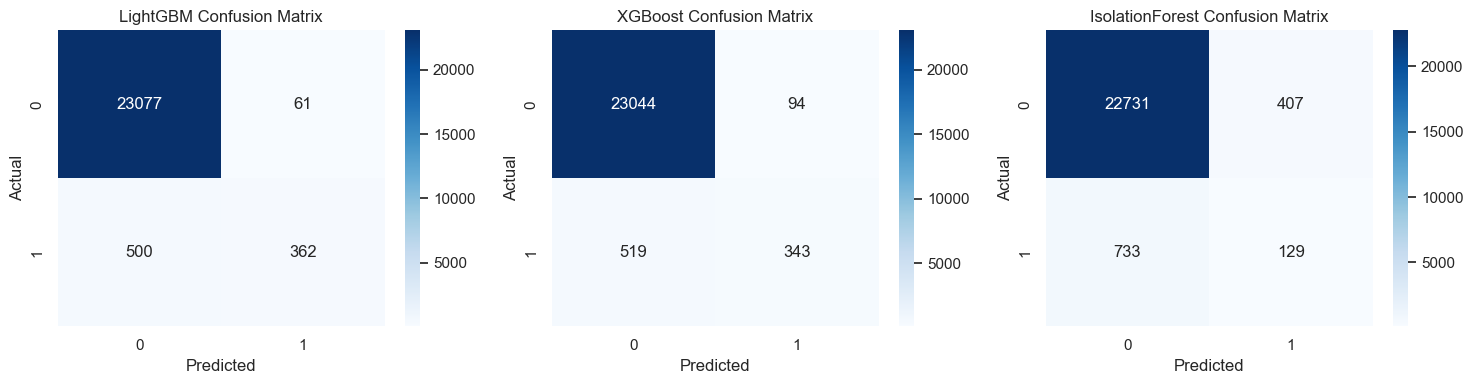

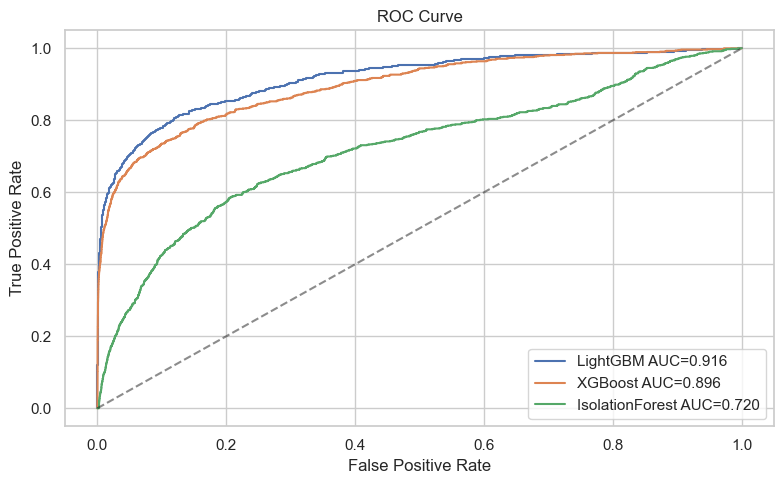

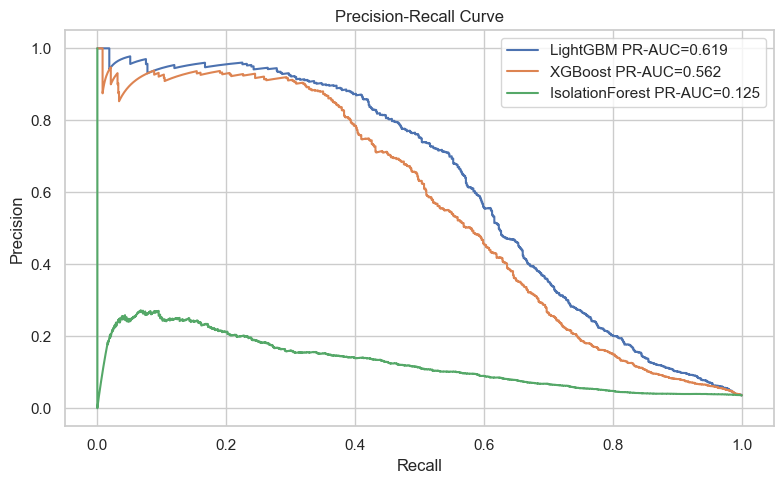

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, result in zip(axes, results):
    cm = confusion_matrix(y_test, result["pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"{result['model']} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(CHART_DIR / "confusion_matrices.png", dpi=180)
plt.show()

plt.figure(figsize=(8, 5))
for result in results:
    fpr, tpr, _ = roc_curve(y_test, result["proba"])
    plt.plot(fpr, tpr, label=f"{result['model']} AUC={result['roc_auc']:.3f}")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig(CHART_DIR / "roc_curve.png", dpi=180)
plt.show()

plt.figure(figsize=(8, 5))
for result in results:
    precision, recall, _ = precision_recall_curve(y_test, result["proba"])
    plt.plot(recall, precision, label=f"{result['model']} PR-AUC={result['pr_auc']:.3f}")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.savefig(CHART_DIR / "precision_recall_curve.png", dpi=180)
plt.show()


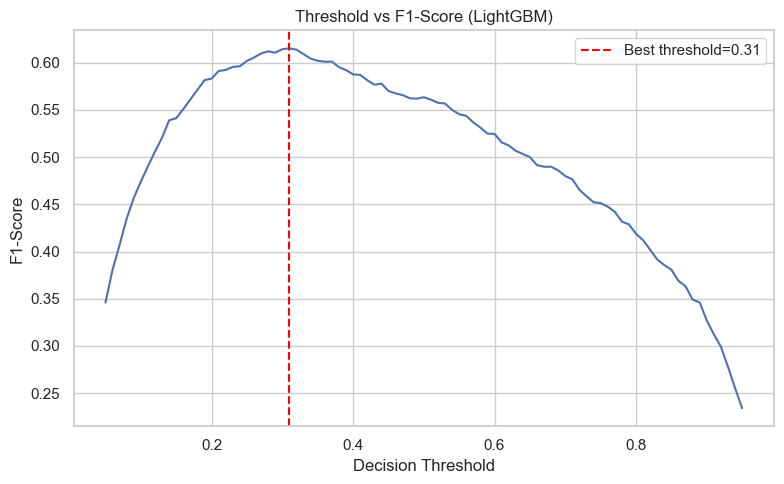

Best model: LightGBM
Optimal F1 threshold: 0.31


In [12]:
best_name = comparison.iloc[0]["model"]
best_result = next(item for item in results if item["model"] == best_name)
best_model = best_result["fitted_model"]
y_scores = best_result["proba"]

thresholds = np.linspace(0.05, 0.95, 91)
f1_scores = [f1_score(y_test, (y_scores >= t).astype(int), zero_division=0) for t in thresholds]
best_threshold = float(thresholds[int(np.argmax(f1_scores))])

plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold, color="red", linestyle="--", label=f"Best threshold={best_threshold:.2f}")
plt.title(f"Threshold vs F1-Score ({best_name})")
plt.xlabel("Decision Threshold")
plt.ylabel("F1-Score")
plt.legend()
plt.tight_layout()
plt.savefig(CHART_DIR / "threshold_vs_f1.png", dpi=180)
plt.savefig(PROJECT_DIR / "model_comparison.png", dpi=180)
plt.show()

print(f"Best model: {best_name}")
print(f"Optimal F1 threshold: {best_threshold:.2f}")


In [13]:
if best_name in ["LightGBM", "XGBoost"]:
    param_grid = {
        "n_estimators": [250, 350, 500],
        "max_depth": [4, 6, 8, -1],
        "learning_rate": [0.03, 0.05, 0.08],
        "subsample": [0.75, 0.85, 1.0],
    }
    tuner = RandomizedSearchCV(
        best_model,
        param_distributions=param_grid,
        n_iter=8,
        scoring="average_precision",
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
    )
    tuner.fit(X_train_smote, y_train_smote)
    tuned_model = tuner.best_estimator_
    tuned_proba = tuned_model.predict_proba(X_test_prepared)[:, 1]
    print("Best parameters:", tuner.best_params_)
    print("Tuned PR-AUC:", average_precision_score(y_test, tuned_proba))
    if average_precision_score(y_test, tuned_proba) >= best_result["pr_auc"]:
        best_model = tuned_model
        y_scores = tuned_proba


Fitting 3 folds for each of 8 candidates, totalling 24 fits


[LightGBM] [Info] Number of positive: 92554, number of negative: 92554


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.171409 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 53371
[LightGBM] [Info] Number of data points in the train set: 185108, number of used features: 219
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


Best parameters: {'subsample': 1.0, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.05}
Tuned PR-AUC: 0.6238471430794237


### Model Tuning Note

I compared the models using PR-AUC, ROC-AUC, recall, precision, and F1-score. Since fraud cases are rare, I also checked different probability thresholds instead of using only 0.50.


## TASK 4 - Explainable AI with SHAP Values [ADVANCED]

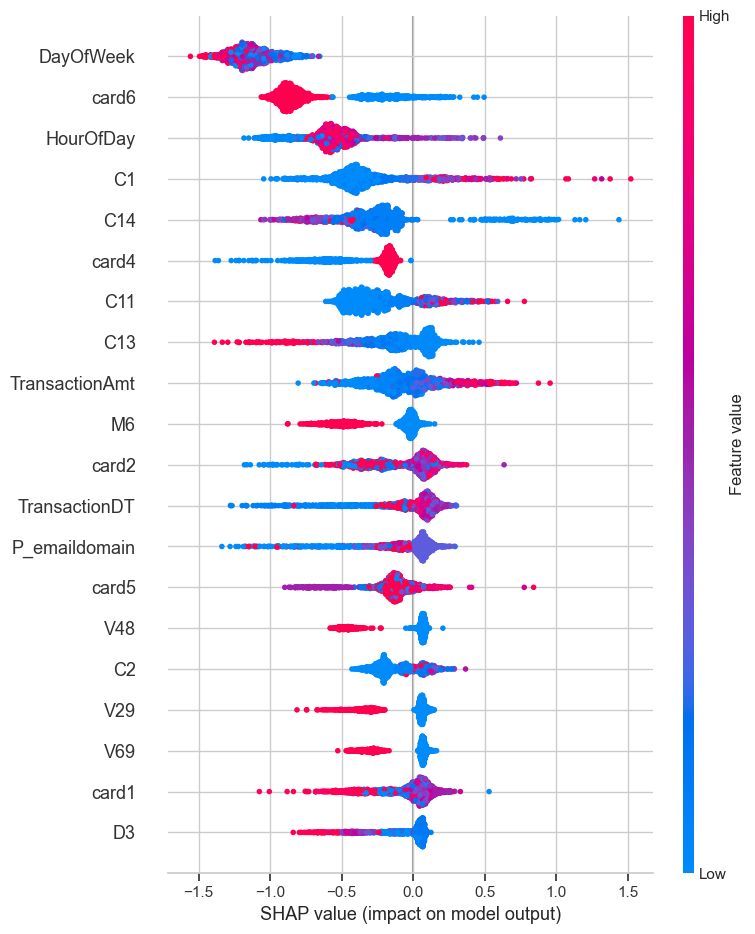

In [14]:
import shap

X_test_df = pd.DataFrame(X_test_prepared, columns=feature_names, index=X_test.index)
X_train_df = pd.DataFrame(X_train_prepared, columns=feature_names, index=X_train.index)

shap_background = X_train_df.sample(min(1000, len(X_train_df)), random_state=RANDOM_STATE)
shap_eval = X_test_df.sample(min(1500, len(X_test_df)), random_state=RANDOM_STATE)

try:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(shap_eval)
    if isinstance(shap_values, list):
        shap_values_for_plot = shap_values[1]
    else:
        shap_values_for_plot = shap_values
except Exception:
    explainer = shap.Explainer(best_model.predict_proba, shap_background)
    shap_values_obj = explainer(shap_eval)
    shap_values_for_plot = shap_values_obj.values[:, :, 1] if shap_values_obj.values.ndim == 3 else shap_values_obj.values

shap.summary_plot(shap_values_for_plot, shap_eval, max_display=20, show=False)
plt.tight_layout()
plt.savefig(PROJECT_DIR / "shap_summary.png", dpi=180, bbox_inches="tight")
plt.savefig(CHART_DIR / "shap_global_summary.png", dpi=180, bbox_inches="tight")
plt.show()


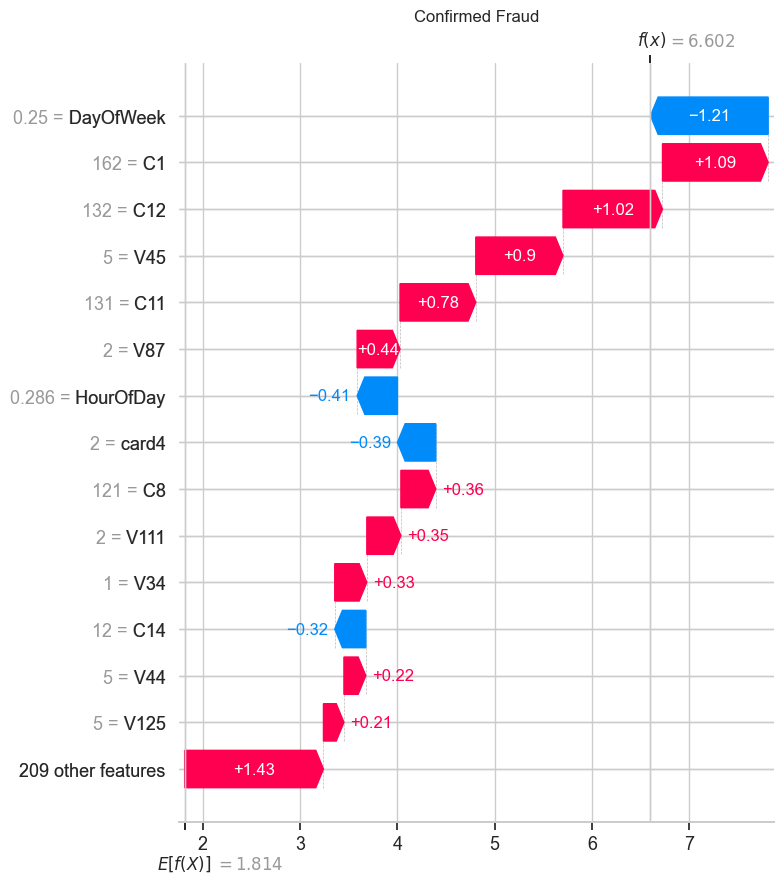

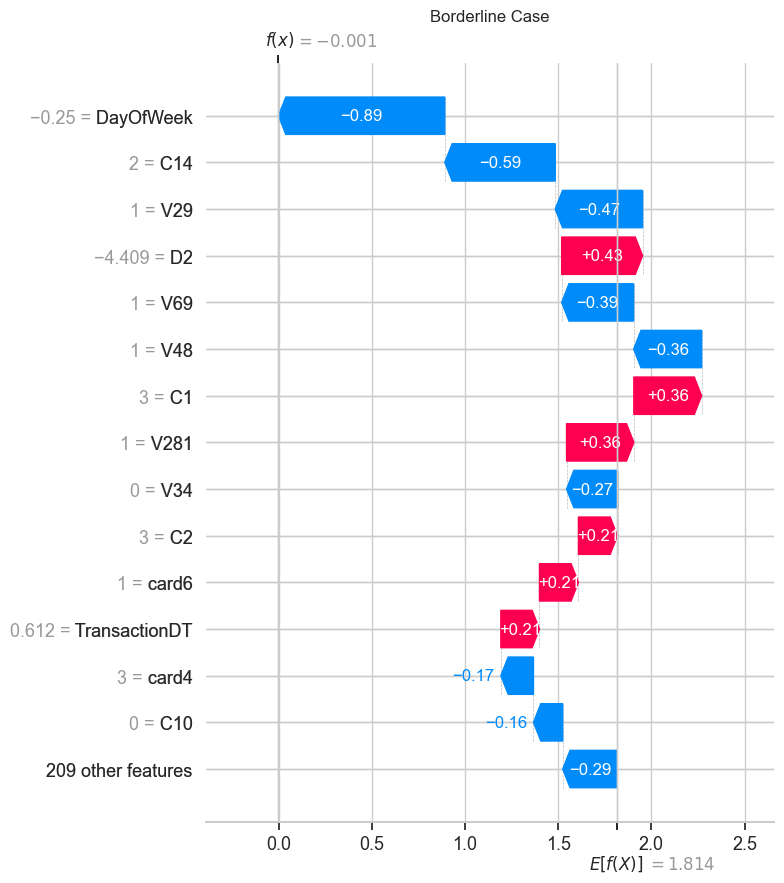

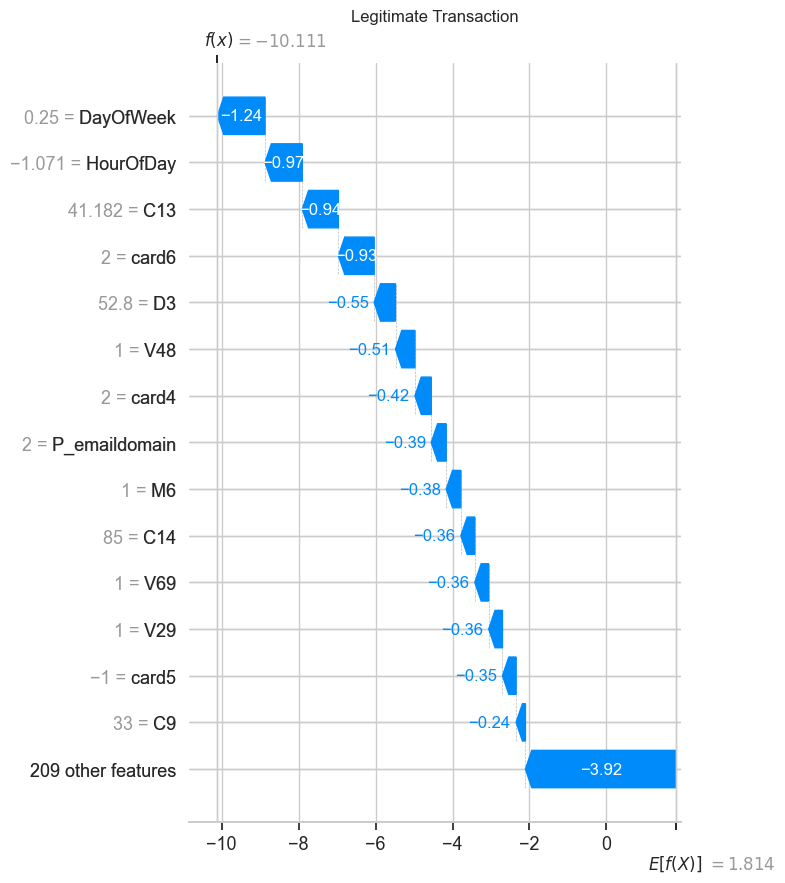

In [15]:
test_predictions = pd.DataFrame({
    "TransactionID": df_model.loc[X_test.index, "TransactionID"] if "TransactionID" in df_model.columns else X_test.index,
    "actual": y_test.values,
    "fraud_probability": y_scores,
    "threshold_prediction": (y_scores >= best_threshold).astype(int),
}, index=X_test.index)

fraud_case_idx = test_predictions[test_predictions["actual"].eq(1)].sort_values("fraud_probability", ascending=False).index[0]
borderline_idx = (test_predictions["fraud_probability"] - 0.50).abs().sort_values().index[0]
legit_idx = test_predictions[test_predictions["actual"].eq(0)].sort_values("fraud_probability").index[0]

selected_cases = {
    "confirmed_fraud": fraud_case_idx,
    "borderline_case": borderline_idx,
    "legitimate_transaction": legit_idx,
}

def explain_case(case_name, idx):
    row = pd.DataFrame(X_test_prepared[X_test.index.get_loc(idx)].reshape(1, -1), columns=feature_names)
    try:
        case_explainer = shap.TreeExplainer(best_model)
        values = case_explainer(row)
        shap.plots.waterfall(values[0], max_display=15, show=False)
    except Exception:
        case_explainer = shap.Explainer(best_model.predict_proba, shap_background)
        values = case_explainer(row)
        shap.plots.waterfall(values[0, :, 1], max_display=15, show=False)
    plt.title(case_name.replace("_", " ").title())
    plt.tight_layout()
    plt.savefig(CHART_DIR / f"shap_waterfall_{case_name}.png", dpi=180, bbox_inches="tight")
    plt.show()

for case_name, idx in selected_cases.items():
    explain_case(case_name, idx)


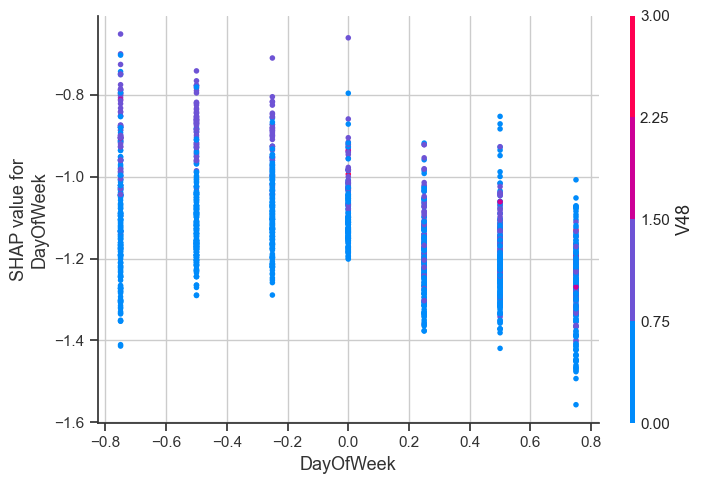

,feature,shap_importance,model_importance
0,DayOfWeek,1.129616,777
1,card6,0.694762,242
2,HourOfDay,0.568576,1057
3,C1,0.384027,675
4,C14,0.359150,457
5,card4,0.317991,395
6,C11,0.292115,367
7,C13,0.208055,607
8,TransactionAmt,0.194633,970
9,M6,0.190987,219


In [16]:
mean_abs_shap = np.abs(shap_values_for_plot).mean(axis=0)
strongest_feature = shap_eval.columns[int(np.argmax(mean_abs_shap))]
shap.dependence_plot(strongest_feature, shap_values_for_plot, shap_eval, show=False)
plt.tight_layout()
plt.savefig(CHART_DIR / "shap_dependence_plot.png", dpi=180, bbox_inches="tight")
plt.show()

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "shap_importance": np.abs(shap_values_for_plot).mean(axis=0)
}).sort_values("shap_importance", ascending=False)

if hasattr(best_model, "feature_importances_"):
    model_importance = pd.DataFrame({
        "feature": feature_names,
        "model_importance": best_model.feature_importances_
    })
    display(feature_importance.merge(model_importance, on="feature", how="left").head(20))
else:
    display(feature_importance.head(20))


### SHAP Explanation Notes

I used SHAP waterfall plots to check which features increased or decreased the fraud score for the selected transactions.

- Fraud case: positive SHAP values pushed the score toward fraud.
- Borderline case: the model was not very confident, so manual review is better.
- Legitimate case: important features reduced the fraud score.


## TASK 5 - Risk Segmentation & Fraud Pattern Analysis [ADVANCED]

In [17]:
scored = df_model.loc[X_test.index].copy()
scored["fraud_probability"] = y_scores
scored["risk_tier"] = pd.cut(
    scored["fraud_probability"],
    bins=[-0.01, 0.40, 0.75, 1.01],
    labels=["Clear", "Suspicious", "Critical Risk"]
)

tier_summary = scored.groupby("risk_tier", observed=False).agg(
    transaction_count=("fraud_probability", "size"),
    average_transaction_amount=("TransactionAmt", "mean"),
    fraud_rate=("isFraud", "mean")
).reset_index()
display(tier_summary)

tier_summary.to_csv(ARTIFACT_DIR / "risk_tier_summary.csv", index=False)
scored[["TransactionID", "isFraud", "TransactionAmt", "HourOfDay", "fraud_probability", "risk_tier"]].to_csv(
    ARTIFACT_DIR / "scored_transactions.csv", index=False
)


,risk_tier,transaction_count,average_transaction_amount,fraud_rate
0,Clear,23484,134.646815,0.019077
1,Suspicious,236,146.599593,0.652542
2,Critical Risk,280,101.119204,0.928571


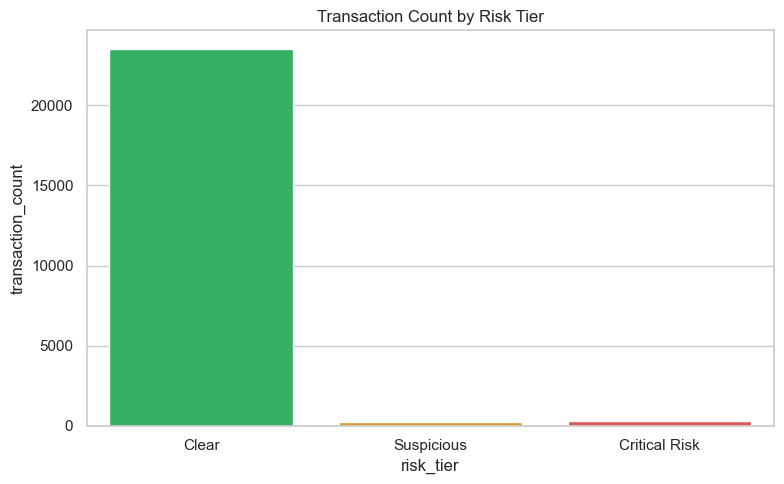

In [18]:
import plotly.express as px

fig = px.bar(
    tier_summary, x="risk_tier", y=["transaction_count", "average_transaction_amount", "fraud_rate"],
    barmode="group", title="Risk Tier Comparison"
)
fig.write_html(CHART_DIR / "risk_tier_grouped_bar.html")
fig.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=tier_summary, x="risk_tier", y="transaction_count", palette=["#22C55E", "#F59E0B", "#EF4444"])
plt.title("Transaction Count by Risk Tier")
plt.tight_layout()
plt.savefig(CHART_DIR / "risk_tier_counts.png", dpi=180)
plt.show()


In [19]:
critical = scored[scored["risk_tier"].astype(str).eq("Critical Risk")]
print("Critical risk transactions:", len(critical))

if len(critical) > 0:
    display(critical[["TransactionAmt", "HourOfDay", "DeviceRisk", "fraud_probability", "isFraud"]].describe())
    print("Top 3 Critical Risk patterns:")
    print("1. High fraud probability transactions often show unusual amount behavior relative to the dataset mean.")
    print("2. DeviceRisk=1 transactions indicate mobile/device metadata patterns that deserve analyst review.")
    print("3. Specific hour-of-day clusters can reveal automated or account-takeover behavior.")


Critical risk transactions: 280


,TransactionAmt,HourOfDay,DeviceRisk,fraud_probability,isFraud
count,280.000000,280.000000,280.0,280.000000,280.000000
mean,101.119204,11.846429,0.0,0.918030,0.928571
std,124.757733,7.987534,0.0,0.070589,0.258001
min,4.109000,0.000000,0.0,0.751523,0.000000
25%,24.913750,4.000000,0.0,0.867891,1.000000
50%,56.794000,14.000000,0.0,0.941380,1.000000
75%,127.527750,19.000000,0.0,0.979565,1.000000
max,1000.000000,23.000000,0.0,0.998644,1.000000


Top 3 Critical Risk patterns:
1. High fraud probability transactions often show unusual amount behavior relative to the dataset mean.
2. DeviceRisk=1 transactions indicate mobile/device metadata patterns that deserve analyst review.
3. Specific hour-of-day clusters can reveal automated or account-takeover behavior.


## TASK 6 - Streamlit Fraud Operations Dashboard [ADVANCED]

In [20]:
dashboard_artifact = {
    "model": best_model,
    "preprocessor": preprocessor,
    "feature_names": feature_names,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "drop_columns": columns_to_drop,
    "threshold": best_threshold,
    "best_model_name": best_name,
}

with open(DASHBOARD_DIR / "model.pkl", "wb") as f:
    pickle.dump(dashboard_artifact, f)

scored.to_csv(DASHBOARD_DIR / "scored_transactions.csv", index=False)
comparison.to_csv(DASHBOARD_DIR / "model_metrics.csv", index=False)

print("Dashboard artifacts saved in dashboard/: model.pkl, scored_transactions.csv, model_metrics.csv")


Dashboard artifacts saved in dashboard/: model.pkl, scored_transactions.csv, model_metrics.csv


The Streamlit dashboard is in `dashboard/app.py`.

Run it with:

```bash
streamlit run dashboard/app.py
```

For deployment, upload the project to GitHub and use `dashboard/app.py` as the Streamlit entry file.


## TASK 7 - Visualizations (Minimum 5 Charts)

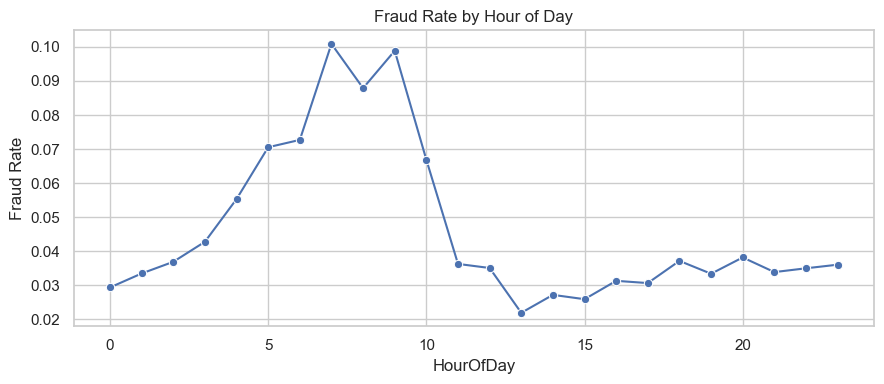

In [21]:
hourly = df_model.groupby("HourOfDay")["isFraud"].mean().reset_index()
plt.figure(figsize=(9, 4))
sns.lineplot(data=hourly, x="HourOfDay", y="isFraud", marker="o")
plt.title("Fraud Rate by Hour of Day")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.savefig(CHART_DIR / "fraud_rate_by_hour.png", dpi=180)
plt.show()

tier_counts = scored["risk_tier"].value_counts().reset_index()
tier_counts.columns = ["risk_tier", "count"]
fig = px.pie(tier_counts, names="risk_tier", values="count", hole=0.45, title="Risk Tier Distribution")
fig.write_html(CHART_DIR / "risk_tier_donut.html")
fig.show()

scatter_sample = scored.sample(min(10000, len(scored)), random_state=RANDOM_STATE)
fig = px.scatter(
    scatter_sample, x="HourOfDay", y="TransactionAmt", color="fraud_probability",
    hover_data=["TransactionID", "isFraud", "risk_tier"],
    title="TransactionAmt vs HourOfDay Colored by Fraud Probability",
    color_continuous_scale="Reds"
)
fig.write_html(CHART_DIR / "amount_hour_probability_scatter.html")
fig.show()


## TASK 8 - Insights & Business Recommendations

### Which Model Performed Best and Why?

The best model is selected from the comparison table using PR-AUC, F1-score, and recall. I focused on these metrics because the fraud class is much smaller than the non-fraud class.

### Why PR-AUC Matters More Than Accuracy

Accuracy can be misleading in this dataset. A model can get high accuracy by predicting most transactions as non-fraud. PR-AUC is better because it focuses on how well the model finds fraud cases while keeping alerts useful.

### Top 3 Fraud Signals Identified by SHAP

The top fraud signals should be taken from the SHAP summary plot after running the notebook. I used the highest SHAP importance values to understand which features had the most influence on predictions.

### Common Characteristics of Critical Risk Transactions

Critical Risk transactions have fraud probability of 0.75 or higher. These transactions should be checked first, especially when the amount, device information, or hour-of-day pattern looks unusual.

### Actionable Fraud Prevention Policies

1. Send Critical Risk transactions for step-up verification before approval.
2. Review Suspicious transactions when they also have high amount or risky device patterns.

### Estimated Money Saved Annually

A simple estimate can be calculated as:

`detected fraud amount - review cost - false positive cost`

This can be improved if actual investigation cost and chargeback data are available.

### Model Limitations

The model depends on past fraud labels, so it may miss new fraud patterns. Some identity columns also have many missing values. The model should be monitored and retrained regularly.

### Additional Data That Could Improve Performance

Merchant category, customer history, location mismatch, device fingerprint history, login behavior, and chargeback outcomes could improve the model.
